In [1]:
# =========================
# Block 0 (FIXED): Common
# =========================

import os
import io
import json
import time
import math
import random
import zipfile
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -------------------------
# Repro / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------
# Run dir
# -------------------------
def make_run_dir(base: str = "artifacts") -> str:
    ts = time.strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(base, f"run_{ts}")
    os.makedirs(run_dir, exist_ok=True)
    return run_dir

RUN_DIR = make_run_dir()
print("RUN_DIR:", RUN_DIR)

def save_json(path: str, obj) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

# -------------------------
# Config
# -------------------------
@dataclass
class CFG:
    zip_path: str = "./data.zip"

    # ROI auto selection
    roi_percentile: float = 99.3
    roi_min_pixels: int = 12
    roi_max_pixels: int = 200

    # normalize
    eps: float = 1e-8

    # path globs inside zip
    odmr_loc_glob: str = "fig_5/fig_5b/fig_5b_loc_"
    rabi_loc_glob: str = "fig_5/fig_5c/fig_5c_loc_"

    # assumed axes (if missing in zip)
    rabi_x_min_ns: float = 6.0
    rabi_x_max_ns: float = 65.0
    odmr_x_min_mhz: float = -60.0
    odmr_x_max_mhz: float = 60.0

    # training
    batch_size: int = 64
    epochs_gan: int = 200
    epochs_ddpm: int = 120
    epochs_t2: int = 120
    z_dim: int = 64
    lr: float = 2e-4

cfg = CFG()
save_json(os.path.join(RUN_DIR, "config.json"), asdict(cfg))

# ============================================================
# ZIP helpers
# ============================================================
def zip_read_json(path_in_zip: str) -> dict:
    with zipfile.ZipFile(cfg.zip_path, "r") as zf:
        with zf.open(path_in_zip) as f:
            return json.load(f)

def zip_read_npz_arr0(path_in_zip: str) -> np.ndarray:
    with zipfile.ZipFile(cfg.zip_path, "r") as zf:
        raw = zf.read(path_in_zip)
    return np.load(io.BytesIO(raw), allow_pickle=True)["arr_0"]

# ============================================================
# ROI + curve extraction
# ============================================================
def choose_auto_roi(
    counts_xy: np.ndarray,
    percentile: float = 99.3,
    min_pix: int = 12,
    max_pix: int = 200
) -> np.ndarray:
    thr = np.percentile(counts_xy, percentile)
    mask = counts_xy >= thr
    n = int(mask.sum())

    # Expand ROI if too small
    if n < min_pix:
        p = percentile
        while n < min_pix and p > 90.0:
            p -= 1.0
            thr = np.percentile(counts_xy, p)
            mask = counts_xy >= thr
            n = int(mask.sum())

    # Shrink ROI if too large
    if n > max_pix:
        p = percentile
        while n > max_pix and p < 99.99:
            p += 0.2
            thr = np.percentile(counts_xy, p)
            mask = counts_xy >= thr
            n = int(mask.sum())

    return mask

def resize_bool_mask_nearest(mask: np.ndarray, target_xy: Tuple[int, int]) -> np.ndarray:
    """Resize a 2D boolean mask to target shape using nearest-neighbor index mapping."""
    mask = np.asarray(mask, dtype=bool)
    sx, sy = mask.shape
    tx, ty = map(int, target_xy)
    if sx <= 0 or sy <= 0 or tx <= 0 or ty <= 0:
        raise ValueError(f"Invalid resize from {mask.shape} to {target_xy}")
    x_idx = np.clip(np.round(np.linspace(0, sx - 1, tx)).astype(int), 0, sx - 1)
    y_idx = np.clip(np.round(np.linspace(0, sy - 1, ty)).astype(int), 0, sy - 1)
    out = mask[np.ix_(x_idx, y_idx)]
    return out.astype(bool)


def align_roi_mask_to_shape(roi_mask: np.ndarray, target_xy: Tuple[int, int], mask_name: str = "roi_mask") -> np.ndarray:
    """
    Align a 2D ROI mask to a target (X,Y) spatial shape.
    Priority:
      1) exact match
      2) transpose match
      3) nearest-neighbor resize
      4) transpose + nearest-neighbor resize
    This handles both axis flips and spatial-resolution mismatches such as 10x10 -> 31x31.
    """
    roi_mask = np.asarray(roi_mask, dtype=bool)
    target_xy = tuple(map(int, target_xy))
    if roi_mask.ndim != 2:
        raise ValueError(f"{mask_name} must be 2D, got shape={roi_mask.shape}")
    if tuple(roi_mask.shape) == target_xy:
        return roi_mask
    if tuple(roi_mask.T.shape) == target_xy:
        print(f"[roi-align] {mask_name} transposed from {roi_mask.shape} -> {target_xy}")
        return roi_mask.T.copy()

    resized = resize_bool_mask_nearest(roi_mask, target_xy)
    if int(resized.sum()) > 0:
        print(f"[roi-align] {mask_name} resized from {roi_mask.shape} -> {target_xy}")
        return resized

    resized_t = resize_bool_mask_nearest(roi_mask.T, target_xy)
    if int(resized_t.sum()) > 0:
        print(f"[roi-align] {mask_name} transposed+resized from {roi_mask.shape} -> {target_xy}")
        return resized_t

    raise IndexError(
        f"{mask_name} shape {roi_mask.shape} could not be aligned to target spatial shape {target_xy}."
    )



def resize_2d_nearest(arr2d: np.ndarray, target_xy: Tuple[int, int]) -> np.ndarray:
    """Resize a 2D numeric array to target shape using nearest-neighbor index mapping."""
    arr2d = np.asarray(arr2d)
    if arr2d.ndim != 2:
        raise ValueError(f"resize_2d_nearest expects 2D input, got shape={arr2d.shape}")
    sx, sy = arr2d.shape
    tx, ty = map(int, target_xy)
    if sx <= 0 or sy <= 0 or tx <= 0 or ty <= 0:
        raise ValueError(f"Invalid resize from {arr2d.shape} to {target_xy}")
    x_idx = np.clip(np.round(np.linspace(0, sx - 1, tx)).astype(int), 0, sx - 1)
    y_idx = np.clip(np.round(np.linspace(0, sy - 1, ty)).astype(int), 0, sy - 1)
    return arr2d[np.ix_(x_idx, y_idx)].copy()

def align_numeric_map_to_shape(arr2d: np.ndarray, target_xy: Tuple[int, int], map_name: str = "map") -> np.ndarray:
    """
    Align a 2D numeric map to a target (X,Y) spatial shape.
    Priority:
      1) exact match
      2) transpose match
      3) nearest-neighbor resize
      4) transpose + nearest-neighbor resize
    """
    arr2d = np.asarray(arr2d, dtype=np.float32)
    target_xy = tuple(map(int, target_xy))
    if arr2d.ndim != 2:
        raise ValueError(f"{map_name} must be 2D, got shape={arr2d.shape}")
    if tuple(arr2d.shape) == target_xy:
        return arr2d
    if tuple(arr2d.T.shape) == target_xy:
        print(f"[map-align] {map_name} transposed from {arr2d.shape} -> {target_xy}")
        return arr2d.T.copy()
    resized = resize_2d_nearest(arr2d, target_xy)
    print(f"[map-align] {map_name} resized from {arr2d.shape} -> {target_xy}")
    return resized

def extract_curve_from_stack(arr0: np.ndarray, roi_mask: np.ndarray = None) -> Tuple[np.ndarray, np.ndarray]:
    """
    arr0: (X, Y, S, B)
    - Sum over bins -> (X,Y,S)
    - ROI avg -> (S,)
    """
    if arr0.ndim != 4:
        raise ValueError(f"Expected 4D (X,Y,S,B), got shape={arr0.shape}")

    # brightness map for ROI
    bright = arr0.sum(axis=(2, 3))

    if roi_mask is None:
        roi_mask = choose_auto_roi(
            bright,
            percentile=cfg.roi_percentile,
            min_pix=cfg.roi_min_pixels,
            max_pix=cfg.roi_max_pixels
        )
    else:
        roi_mask = align_roi_mask_to_shape(roi_mask, bright.shape, mask_name="roi_mask")

    counts_xys = arr0.sum(axis=3)      # (X,Y,S)
    roi_vals = counts_xys[roi_mask]    # (Npix,S)
    if roi_vals.size == 0:
        raise ValueError(f"ROI is empty after alignment for stack shape={arr0.shape}")
    curve = roi_vals.mean(axis=0)      # (S,)
    return curve.astype(np.float32), roi_mask

def robust_normalize_curve(y: np.ndarray) -> np.ndarray:
    y = y.astype(np.float32)
    lo = np.percentile(y, 5)
    hi = np.percentile(y, 95)
    if abs(hi - lo) < cfg.eps:
        return np.zeros_like(y)
    y01 = np.clip((y - lo) / (hi - lo), 0.0, 1.0)
    return (2.0 * y01 - 1.0).astype(np.float32)

# ============================================================
# ODMR -> condition features
# ============================================================
def odmr_features(y_norm: np.ndarray) -> np.ndarray:
    y = y_norm
    dip = float(np.min(y))
    edge = max(3, len(y) // 10)
    base = float(np.median(np.r_[y[:edge], y[-edge:]]))
    depth = float(base - dip)

    imin = int(np.argmin(y))
    half = base - 0.5 * depth
    l = imin
    while l > 0 and y[l] < half:
        l -= 1
    r = imin
    while r < len(y) - 1 and y[r] < half:
        r += 1
    lw_idx = float(max(1, r - l))

    dy = np.gradient(y)
    slope = float(np.max(np.abs(dy)))

    mu = float(np.mean(y))
    sig = float(np.std(y))
    return np.array([depth, lw_idx / len(y), slope, mu, sig], dtype=np.float32)

COND_DIM = 5

# ============================================================
# Models: GAN + DDPM + T2 predictor
# ============================================================
class RabiGenerator(nn.Module):
    def __init__(self, z_dim: int = 64, cond_dim: int = COND_DIM, out_len: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + cond_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, out_len),
            nn.Tanh()
        )

    def forward(self, z: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([z, cond], dim=1))

class RabiDiscriminator(nn.Module):
    def __init__(self, cond_dim: int = COND_DIM, in_len: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_len + cond_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x, cond], dim=1))

# ---- DDPM ----
def make_beta_schedule(T: int, beta_start: float = 1e-4, beta_end: float = 2e-2, device: str = "cpu"):
    betas = torch.linspace(beta_start, beta_end, T, device=device)
    alphas = 1.0 - betas
    abar = torch.cumprod(alphas, dim=0)
    return betas, alphas, abar

def timestep_embedding(t: torch.Tensor, dim: int):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / half)
    args = t[:, None].float() * freqs[None, :]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

class Denoiser1D(nn.Module):
    def __init__(self, x_len: int = 64, cond_dim: int = COND_DIM, t_dim: int = 64):
        super().__init__()
        self.t_dim = t_dim
        self.fc_t = nn.Linear(t_dim, 128)
        self.fc_c = nn.Linear(cond_dim, 128)
        self.net = nn.Sequential(
            nn.Linear(x_len + 128 + 128, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, x_len),
        )

    def forward(self, x_t: torch.Tensor, t: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        te = timestep_embedding(t, self.t_dim)
        ht = self.fc_t(te)
        hc = self.fc_c(cond)
        return self.net(torch.cat([x_t, ht, hc], dim=1))

class ConditionalDDPM:
    def __init__(self, denoiser: nn.Module, T: int = 200, device: str = "cpu"):
        self.denoiser = denoiser
        self.T = T
        self.device = device
        self.betas, self.alphas, self.abar = make_beta_schedule(T, device=device)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor = None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.abar[t].unsqueeze(1)
        return torch.sqrt(a) * x0 + torch.sqrt(1.0 - a) * noise, noise

    def loss(self, x0: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        B = x0.size(0)
        t = torch.randint(0, self.T, (B,), device=x0.device, dtype=torch.long)
        xt, eps = self.q_sample(x0, t)
        eps_hat = self.denoiser(xt, t, cond)
        return ((eps_hat - eps) ** 2).mean()

    @torch.no_grad()
    def sample_from(self, x_init: torch.Tensor, cond: torch.Tensor, cfg_scale: float = 1.7) -> torch.Tensor:
        x = x_init.clone()
        B = x.size(0)
        cond0 = torch.zeros_like(cond)
        for ti in reversed(range(self.T)):
            t = torch.full((B,), ti, device=x.device, dtype=torch.long)
            eps_c = self.denoiser(x, t, cond)
            eps_u = self.denoiser(x, t, cond0)
            eps = eps_u + cfg_scale * (eps_c - eps_u)

            beta = self.betas[t].unsqueeze(1)
            alpha = self.alphas[t].unsqueeze(1)
            abar = self.abar[t].unsqueeze(1)

            z = torch.randn_like(x) if ti > 0 else torch.zeros_like(x)
            x = (1.0 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1.0 - abar)) * eps) + torch.sqrt(beta) * z
        return torch.clamp(x, -1.0, 1.0)

# ---- T2* proxy + predictor ----
def estimate_T2star_from_rabi_index(x_ns: np.ndarray, y: np.ndarray) -> float:
    x = x_ns.astype(np.float32)
    yy = np.abs(y).astype(np.float32)
    yy = np.clip(yy, 1e-6, None)
    yy_s = np.convolve(yy, np.ones(7) / 7, mode="same")

    mask = (np.arange(len(x)) > 5) & (np.arange(len(x)) < len(x) - 5)
    x2, y2 = x[mask], yy_s[mask]
    keep = y2 > np.percentile(y2, 25)
    x2, y2 = x2[keep], y2[keep]
    if len(x2) < 10:
        return float("nan")

    A = np.vstack([np.ones_like(x2), x2]).T
    beta = np.linalg.lstsq(A, np.log(y2), rcond=None)[0]
    slope = beta[1]
    if slope >= 0:
        return float("nan")
    T2s = -1.0 / slope
    return float(np.clip(T2s, 1.0, 500.0))

class T2PredictorNN(nn.Module):
    def __init__(self, x_len: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_len, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, rabi: torch.Tensor) -> torch.Tensor:
        return self.net(rabi)

def save_trend_plot(trend: List[dict], keys: List[str], title: str, out_png: str):
    plt.figure(figsize=(10, 4))
    for k in keys:
        plt.plot([t["epoch"] for t in trend], [t[k] for t in trend], label=k)
    plt.xlabel("epoch")
    plt.grid(True)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()

print("[Block0] Loaded OK.")


# =========================
# ODMR Quantification (contrast / linewidth / slope / sensitivity)
# =========================

def odmr_metrics_from_curve(x_mhz: np.ndarray, y: np.ndarray) -> dict:
    """
    x_mhz: frequency axis in MHz (assumed or recovered)
    y: ODMR curve (can be raw counts or normalized [-1,1])
    Returns: contrast, linewidth_MHz, slope_per_MHz, idx_max_slope
    """
    x = x_mhz.astype(np.float32)
    s = y.astype(np.float32)

    edge = max(3, len(s)//10)
    baseline = float(np.median(np.r_[s[:edge], s[-edge:]]))
    imin = int(np.argmin(s))
    dip = float(s[imin])

    # contrast: (baseline - dip)/baseline
    contrast = float(max(0.0, (baseline - dip) / max(1e-9, abs(baseline))))

    # FWHM in x units (MHz) using half depth
    depth = baseline - dip
    half = baseline - 0.5 * depth
    l = imin
    while l > 0 and s[l] < half:
        l -= 1
    r = imin
    while r < len(s) - 1 and s[r] < half:
        r += 1
    linewidth_mhz = float(np.clip(x[r] - x[l], 1e-6, 1e9))

    # slope = max |ds/dx| (per MHz)
    ds_dx = np.gradient(s, x)
    idx = int(np.argmax(np.abs(ds_dx)))
    slope = float(np.max(np.abs(ds_dx)))

    return {
        "baseline": baseline,
        "dip": dip,
        "contrast": contrast,
        "linewidth_MHz": linewidth_mhz,
        "slope_per_MHz": slope,
        "idx_max_slope": idx
    }

def odmr_sensitivity_uT_per_sqrtHz(
    x_mhz: np.ndarray,
    y: np.ndarray,
    gamma_Hz_per_T: float = 28e9,
    photon_noise_floor: float = 8e-4,
    local_win: int = 8
) -> dict:
    """
    Gradient-based DC sensitivity proxy:
      eta = sigma_S / (|dS/df| * gamma)
    - sigma_S: local noise estimate near max-slope point + photon_noise_floor
    - dS/df: derivative per Hz (convert from per MHz)
    """
    m = odmr_metrics_from_curve(x_mhz, y)
    idx = m["idx_max_slope"]

    s = y.astype(np.float32)
    lo = max(0, idx - local_win)
    hi = min(len(s), idx + local_win + 1)
    local = s[lo:hi]

    # local noise estimate (dimensionless S units)
    sigma_local = float(np.std(local))
    sigma_S = float(np.sqrt(photon_noise_floor**2 + sigma_local**2))

    # slope per Hz: (per MHz)/1e6
    dS_df_per_Hz = abs(m["slope_per_MHz"]) / 1e6

    dS_dB = dS_df_per_Hz * gamma_Hz_per_T  # per Tesla
    if dS_dB < 1e-18:
        eta_T = 1e9
    else:
        eta_T = sigma_S / dS_dB  # T / sqrt(Hz)

    return {
        **m,
        "sigma_S": sigma_S,
        "eta_T_per_sqrtHz": float(eta_T),
        "eta_uT_per_sqrtHz": float(eta_T * 1e6)
    }


DEVICE: cuda
RUN_DIR: artifacts/run_20260324_131950
[Block0] Loaded OK.


ODMR loc npz: 6
RABI loc npz: 4
Example ODMR: ['fig_5/fig_5b/fig_5b_loc_1.npz', 'fig_5/fig_5b/fig_5b_loc_2.npz']
Example RABI: ['fig_5/fig_5c/fig_5c_loc_0.npz', 'fig_5/fig_5c/fig_5c_loc_1.npz']
Common loc ids: [1, 2, 3]
Samples: 3
First sample lens: 62 58
ROI debug (first): {'odmr_shape': (10, 10, 62, 5000), 'rabi_shape': (31, 31, 58, 5000), 'odmr_roi_pixels': 11, 'rabi_roi_pixels': 17}
Unique rabi lengths: [58]
Unique odmr lengths: [62]
X_rabi: torch.Size([3, 58]) C_cond: torch.Size([3, 5])
y_t2: torch.Size([3, 1]) t2(ns) range: 0.0 177.5266571044922
Saved dataset_cache.npz to artifacts/run_20260324_131950


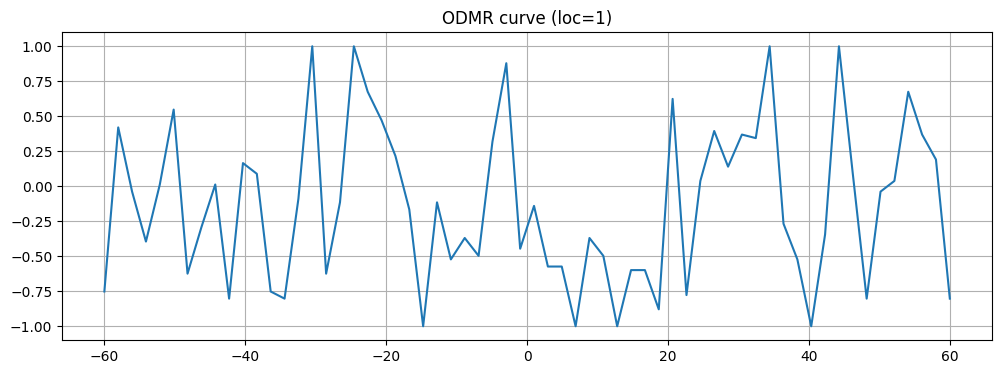

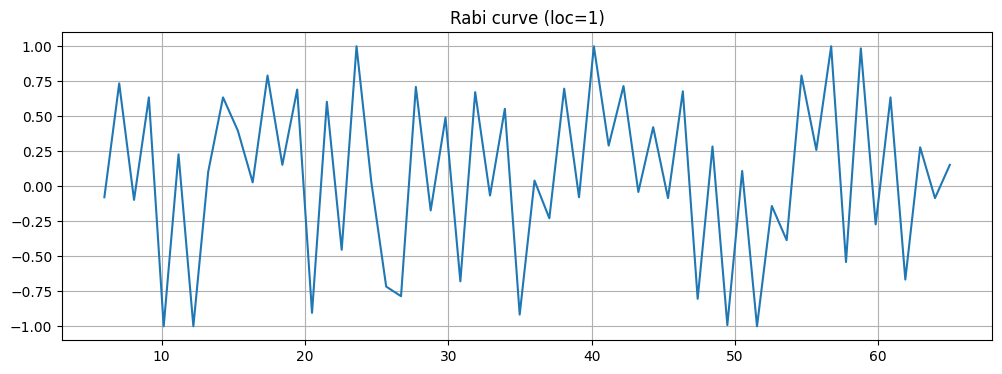

In [2]:
# =========================
# Block 1: Load dataset from data.zip (ROI->curve)
# =========================

# 1) loc 파일 목록 찾기
with zipfile.ZipFile(cfg.zip_path, "r") as zf:
    all_names = zf.namelist()

odmr_npzs = sorted([n for n in all_names if n.startswith(cfg.odmr_loc_glob) and n.endswith(".npz")])
rabi_npzs = sorted([n for n in all_names if n.startswith(cfg.rabi_loc_glob) and n.endswith(".npz")])

print("ODMR loc npz:", len(odmr_npzs))
print("RABI loc npz:", len(rabi_npzs))
print("Example ODMR:", odmr_npzs[:2])
print("Example RABI:", rabi_npzs[:2])

# 2) loc index 맞춰 pair 만들기 (loc_0, loc_1 …)
def loc_id(path):
    # ..._loc_3.npz -> 3
    m = __import__("re").search(r"_loc_(\d+)\.npz$", path)
    return int(m.group(1)) if m else None

odmr_map = {loc_id(p): p for p in odmr_npzs if loc_id(p) is not None}
rabi_map = {loc_id(p): p for p in rabi_npzs if loc_id(p) is not None}

common_ids = sorted(set(odmr_map.keys()) & set(rabi_map.keys()))
print("Common loc ids:", common_ids)

if len(common_ids) == 0:
    raise RuntimeError("ODMR loc와 Rabi loc의 공통 ID가 없습니다. (폴더/파일명 확인 필요)")

# 3) 각 loc에 대해 ROI curve 추출
dataset = []
roi_debug = {}

for i in common_ids:
    odmr_path = odmr_map[i]
    rabi_path = rabi_map[i]

    odmr_arr = zip_read_npz_arr0(odmr_path)   # (X,Y,S,B)
    rabi_arr = zip_read_npz_arr0(rabi_path)

    odmr_curve_raw, roi1 = extract_curve_from_stack(odmr_arr, roi_mask=None)
    rabi_curve_raw, roi2 = extract_curve_from_stack(rabi_arr, roi_mask=None)

    odmr_curve = robust_normalize_curve(odmr_curve_raw)
    rabi_curve = robust_normalize_curve(rabi_curve_raw)

    cond = odmr_features(odmr_curve)

    dataset.append({
        "loc_id": i,
        "odmr_path": odmr_path,
        "rabi_path": rabi_path,
        "odmr_curve": odmr_curve,   # [-1,1]
        "rabi_curve": rabi_curve,   # [-1,1]
        "cond": cond,               # (5,)
        "odmr_len": len(odmr_curve),
        "rabi_len": len(rabi_curve),
    })

    # debug ROI 크기만 저장
    roi_debug[i] = {
        "odmr_shape": odmr_arr.shape,
        "rabi_shape": rabi_arr.shape,
        "odmr_roi_pixels": int(roi1.sum()),
        "rabi_roi_pixels": int(roi2.sum())
    }

print("Samples:", len(dataset))
print("First sample lens:", dataset[0]["odmr_len"], dataset[0]["rabi_len"])
print("ROI debug (first):", roi_debug[common_ids[0]])

save_json(os.path.join(RUN_DIR, "roi_debug.json"), roi_debug)

# 4) 텐서로 변환 (Rabi 길이는 loc마다 같다고 가정. 다르면 resample 필요)
rabi_len_set = sorted(set(d["rabi_len"] for d in dataset))
odmr_len_set = sorted(set(d["odmr_len"] for d in dataset))
print("Unique rabi lengths:", rabi_len_set)
print("Unique odmr lengths:", odmr_len_set)

if len(rabi_len_set) != 1:
    raise RuntimeError("Rabi 길이가 샘플마다 다릅니다. (리샘플링 로직 추가 필요)")
if len(odmr_len_set) != 1:
    raise RuntimeError("ODMR 길이가 샘플마다 다릅니다. (리샘플링 로직 추가 필요)")

RABI_LEN = rabi_len_set[0]
ODMR_LEN = odmr_len_set[0]

# 축(axis) 생성 (zip 내부에 sweep axis가 직접 없어서 기본 가정)
rabi_x_ns = np.linspace(cfg.rabi_x_min_ns, cfg.rabi_x_max_ns, RABI_LEN).astype(np.float32)
odmr_x_mhz = np.linspace(cfg.odmr_x_min_mhz, cfg.odmr_x_max_mhz, ODMR_LEN).astype(np.float32)

X_rabi = torch.tensor(np.stack([d["rabi_curve"] for d in dataset], axis=0), dtype=torch.float32, device=DEVICE)
C_cond = torch.tensor(np.stack([d["cond"] for d in dataset], axis=0), dtype=torch.float32, device=DEVICE)

print("X_rabi:", X_rabi.shape, "C_cond:", C_cond.shape)

# (옵션) T2* proxy label 생성: 실제 fitting이 아니라 envelope 기반 proxy
t2_labels = []
for d in dataset:
    t2_ns = estimate_T2star_from_rabi_index(rabi_x_ns, d["rabi_curve"])
    t2_labels.append(0.0 if np.isnan(t2_ns) else t2_ns)

y_t2 = torch.tensor(np.array(t2_labels, dtype=np.float32)[:,None], device=DEVICE)
print("y_t2:", y_t2.shape, "t2(ns) range:", float(y_t2.min()), float(y_t2.max()))

np.savez_compressed(
    os.path.join(RUN_DIR, "dataset_cache.npz"),
    X_rabi=X_rabi.detach().cpu().numpy(),
    C_cond=C_cond.detach().cpu().numpy(),
    rabi_x_ns=rabi_x_ns,
    odmr_x_mhz=odmr_x_mhz,
    y_t2=y_t2.detach().cpu().numpy(),
)
print("Saved dataset_cache.npz to", RUN_DIR)

# Quick sanity plot (one sample)
k = 0
plt.figure(figsize=(12,4))
plt.plot(odmr_x_mhz, dataset[k]["odmr_curve"])
plt.title(f"ODMR curve (loc={dataset[k]['loc_id']})")
plt.grid(True); plt.show()

plt.figure(figsize=(12,4))
plt.plot(rabi_x_ns, dataset[k]["rabi_curve"])
plt.title(f"Rabi curve (loc={dataset[k]['loc_id']})")
plt.grid(True); plt.show()



# ODMR Spatial Demo Extension

이 섹션은 기존 `data.zip` 경로와 `fig_5/fig_5b`, `fig_5/fig_5c` 구조를 그대로 사용해서 아래 데모를 추가합니다.

- brightness image + on-cell / off-cell ROI
- pixel-wise ODMR depth / linewidth / slope map
- Rabi coherence proxy map
- bootstrap uncertainty map
- effective Hamiltonian-consistent reconstruction (`D`, `E`, linewidth) map

가정:
- 배열 shape은 기존 코드와 동일하게 `(X, Y, S, B)` 입니다.
- ODMR 축이 zip 안에 없으면 기존 `cfg.odmr_x_min_mhz`, `cfg.odmr_x_max_mhz`를 사용합니다.
- Rabi 축이 zip 안에 없으면 기존 `cfg.rabi_x_min_ns`, `cfg.rabi_x_max_ns`를 사용합니다.
- physics-informed reconstruction은 **논문의 exact powder-spectrum 전역 적합**이 아니라, 각 픽셀에 대해 `m_s=0→±1` 유효 2-전이 Lorentzian 모델을 적합하는 **effective local model**입니다.


In [3]:

# =========================
# Block 1A: Spatial demo helpers
# =========================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

DEMO_DIR = os.path.join(RUN_DIR, "spatial_demo")
os.makedirs(DEMO_DIR, exist_ok=True)
print("DEMO_DIR:", DEMO_DIR)

def try_read_axis_from_npz(path_in_zip: str):
    """Best-effort axis recovery from npz keys if present."""
    with zipfile.ZipFile(cfg.zip_path, "r") as zf:
        raw = zf.read(path_in_zip)
    npz = np.load(io.BytesIO(raw), allow_pickle=True)
    keys = list(npz.keys())
    axis_keys = [k for k in keys if k != "arr_0"]
    arr0 = npz["arr_0"]
    axis = None
    for k in axis_keys:
        v = npz[k]
        if isinstance(v, np.ndarray) and v.ndim == 1 and len(v) == arr0.shape[2]:
            axis = v.astype(np.float32)
            print(f"[axis] {path_in_zip} -> key={k}")
            break
    return axis

def make_default_axis(n: int, lo: float, hi: float):
    return np.linspace(lo, hi, n, dtype=np.float32)

def stack_axes_from_paths(odmr_path: str, rabi_path: str, odmr_arr: np.ndarray, rabi_arr: np.ndarray):
    odmr_x = try_read_axis_from_npz(odmr_path)
    if odmr_x is None:
        odmr_x = make_default_axis(odmr_arr.shape[2], cfg.odmr_x_min_mhz, cfg.odmr_x_max_mhz)
    rabi_x = try_read_axis_from_npz(rabi_path)
    if rabi_x is None:
        rabi_x = make_default_axis(rabi_arr.shape[2], cfg.rabi_x_min_ns, cfg.rabi_x_max_ns)
    return odmr_x, rabi_x

def brightness_map(arr4d: np.ndarray):
    return arr4d.sum(axis=(2,3)).astype(np.float32)

def make_on_off_masks(bright: np.ndarray, on_pct: float = 99.3, off_pct: float = 40.0):
    on_mask = choose_auto_roi(bright, percentile=on_pct, min_pix=cfg.roi_min_pixels, max_pix=cfg.roi_max_pixels)
    q = np.percentile(bright, off_pct)
    off_mask = bright <= q
    # keep off-mask away from on-cell region by erosion-like margin using distance-free local neighbor exclusion
    grow = on_mask.copy()
    for _ in range(2):
        g = grow.copy()
        g[:-1, :] |= grow[1:, :]
        g[1:, :] |= grow[:-1, :]
        g[:, :-1] |= grow[:, 1:]
        g[:, 1:] |= grow[:, :-1]
        g[:-1, :-1] |= grow[1:, 1:]
        g[1:, 1:] |= grow[:-1, :-1]
        g[:-1, 1:] |= grow[1:, :-1]
        g[1:, :-1] |= grow[:-1, 1:]
        grow = g
    off_mask = off_mask & (~grow)
    return on_mask, off_mask

def overlay_roi(bright: np.ndarray, on_mask: np.ndarray, off_mask: np.ndarray, title: str, out_png: str):
    fig, ax = plt.subplots(figsize=(6,5))
    ax.imshow(bright.T, origin="lower", aspect="auto")
    yx = np.argwhere(on_mask)
    if len(yx):
        ax.scatter(yx[:,0], yx[:,1], s=18, marker='s', facecolors='none', edgecolors='lime', linewidths=0.6, label='on-cell ROI')
    yx2 = np.argwhere(off_mask)
    if len(yx2):
        ax.scatter(yx2[:,0], yx2[:,1], s=9, marker='s', facecolors='none', edgecolors='cyan', linewidths=0.4, alpha=0.45, label='off-cell ROI')
    ax.set_title(title)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(out_png, dpi=180)
    plt.show()

def smooth1d(y: np.ndarray, k: int = 5):
    if k <= 1:
        return y.astype(np.float32)
    kern = np.ones(k, dtype=np.float32) / k
    return np.convolve(y.astype(np.float32), kern, mode="same")

def norm_curve_unit(y: np.ndarray):
    y = y.astype(np.float32)
    lo = np.percentile(y, 5)
    hi = np.percentile(y, 95)
    if hi - lo < 1e-8:
        return np.zeros_like(y)
    return np.clip((y - lo) / (hi - lo), 0, 1)

def odmr_metrics_raw(x_mhz: np.ndarray, y: np.ndarray):
    s = smooth1d(y, 5)
    edge = max(3, len(s)//10)
    base = float(np.median(np.r_[s[:edge], s[-edge:]]))
    imin = int(np.argmin(s))
    dip = float(s[imin])
    depth = max(0.0, base - dip)
    half = base - 0.5 * depth
    l = imin
    while l > 0 and s[l] < half:
        l -= 1
    r = imin
    while r < len(s)-1 and s[r] < half:
        r += 1
    lw = float(max(x_mhz[min(r, len(x_mhz)-1)] - x_mhz[max(l,0)], 0.0))
    dy = np.gradient(s, x_mhz)
    slope = float(np.max(np.abs(dy)))
    return {"depth": depth, "linewidth_MHz": lw, "slope_per_MHz": slope, "baseline": base, "dip": dip}

def rabi_visibility(y: np.ndarray):
    s = smooth1d(y, 5)
    p05, p95 = np.percentile(s, [5,95])
    return float(max(0.0, p95 - p05))

def moving_envelope(y: np.ndarray, k: int = 7):
    a = np.abs(y - np.median(y)).astype(np.float32)
    return smooth1d(a, k)

def decay_proxy_from_rabi(x_ns: np.ndarray, y: np.ndarray):
    env = moving_envelope(y, 7)
    keep = env > np.percentile(env, 30)
    if int(keep.sum()) < 8:
        return np.nan
    xx = x_ns[keep].astype(np.float32)
    yy = np.clip(env[keep], 1e-6, None)
    A = np.vstack([np.ones_like(xx), xx]).T
    b0, b1 = np.linalg.lstsq(A, np.log(yy), rcond=None)[0]
    if b1 >= 0:
        return np.nan
    return float(-1.0 / b1)

def extract_counts_xys(arr4d: np.ndarray):
    return arr4d.sum(axis=3).astype(np.float32)   # (X,Y,S)

def effective_two_lorentzian_fit(x_mhz: np.ndarray, y: np.ndarray):
    """
    Effective local Hamiltonian-consistent fit:
      S(f) = base - a*[L(f; D-E, g) + L(f; D+E, g)]
    Returns D, E, gamma(linewidth proxy), amplitude, rmse.
    """
    s = smooth1d(y, 5).astype(np.float32)
    base = float(np.median(np.r_[s[:max(3,len(s)//10)], s[-max(3,len(s)//10):]]))
    # search around minimum and a plausible symmetric split
    x = x_mhz.astype(np.float32)
    x0 = float(x[np.argmin(s)])
    x_center = 0.5 * (float(x[0]) + float(x[-1]))
    # D can shift around observed center; E >= 0
    D_grid = np.linspace(x0 - 8.0, x0 + 8.0, 31)
    E_grid = np.linspace(0.5, min(20.0, 0.4 * (x[-1] - x[0])), 30)
    G_grid = np.linspace(max(0.4, (x[1]-x[0])*1.5), max(1.2, 0.15*(x[-1]-x[0])), 24)

    best = None
    ones = np.ones_like(x)
    for D in D_grid:
        for E in E_grid:
            c1, c2 = D - E, D + E
            for g in G_grid:
                L1 = 1.0 / (1.0 + ((x - c1) / g) ** 2)
                L2 = 1.0 / (1.0 + ((x - c2) / g) ** 2)
                A = np.vstack([ones, -(L1 + L2)]).T
                coeff, *_ = np.linalg.lstsq(A, s, rcond=None)
                base_hat, amp_hat = coeff
                pred = A @ coeff
                rmse = float(np.sqrt(np.mean((pred - s) ** 2)))
                if best is None or rmse < best["rmse"]:
                    best = {
                        "D_MHz": float(D),
                        "E_MHz": float(abs(E)),
                        "gamma_MHz": float(g),
                        "amplitude": float(max(0.0, amp_hat)),
                        "baseline": float(base_hat),
                        "rmse": rmse,
                        "pred": pred.astype(np.float32),
                    }
    return best

def bootstrap_depth_ci_per_pixel(counts_xys: np.ndarray, n_boot: int = 40, seed: int = 42):
    """
    Photon-count bootstrap by Poisson resampling counts_xys[x,y,s].
    Returns mean_depth, std_depth, ci_low, ci_high maps.
    """
    rng = np.random.default_rng(seed)
    X, Y, S = counts_xys.shape
    depth_samples = np.zeros((n_boot, X, Y), dtype=np.float32)
    x_idx = np.arange(X)
    y_idx = np.arange(Y)
    x_axis = make_default_axis(S, cfg.odmr_x_min_mhz, cfg.odmr_x_max_mhz)

    for b in range(n_boot):
        samp = rng.poisson(np.clip(counts_xys, 0, None)).astype(np.float32)
        sm = smooth1d(np.zeros(S, dtype=np.float32), 1)  # no-op placeholder
        for i in range(X):
            for j in range(Y):
                depth_samples[b, i, j] = odmr_metrics_raw(x_axis, samp[i, j, :])["depth"]

    mean_map = depth_samples.mean(axis=0)
    std_map = depth_samples.std(axis=0)
    low_map = np.percentile(depth_samples, 2.5, axis=0)
    high_map = np.percentile(depth_samples, 97.5, axis=0)
    return mean_map, std_map, low_map, high_map

def save_map(map2d: np.ndarray, title: str, out_png: str, cmap=None):
    plt.figure(figsize=(6,5))
    plt.imshow(map2d.T, origin='lower', aspect='auto', cmap=cmap)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=180)
    plt.show()

print("[Block1A] Spatial demo helpers ready.")


DEMO_DIR: artifacts/run_20260324_131950/spatial_demo
[Block1A] Spatial demo helpers ready.


In [4]:

# =========================
# Block 1B: Select location + load stacks
# =========================

# pick the first common location by default; change this if needed
demo_loc_id = common_ids[0]
odmr_path = odmr_map[demo_loc_id]
rabi_path = rabi_map[demo_loc_id]

odmr_arr = zip_read_npz_arr0(odmr_path)
rabi_arr = zip_read_npz_arr0(rabi_path)
odmr_x_mhz, rabi_x_ns = stack_axes_from_paths(odmr_path, rabi_path, odmr_arr, rabi_arr)

print("demo_loc_id:", demo_loc_id)
print("ODMR path:", odmr_path, "| shape:", odmr_arr.shape)
print("Rabi path:", rabi_path, "| shape:", rabi_arr.shape)
print("ODMR axis range [MHz]:", float(odmr_x_mhz[0]), "->", float(odmr_x_mhz[-1]), "N=", len(odmr_x_mhz))
print("Rabi axis range [ns]:", float(rabi_x_ns[0]), "->", float(rabi_x_ns[-1]), "N=", len(rabi_x_ns))


demo_loc_id: 1
ODMR path: fig_5/fig_5b/fig_5b_loc_1.npz | shape: (10, 10, 62, 5000)
Rabi path: fig_5/fig_5c/fig_5c_loc_1.npz | shape: (31, 31, 58, 5000)
ODMR axis range [MHz]: -60.0 -> 60.0 N= 62
Rabi axis range [ns]: 6.0 -> 65.0 N= 58


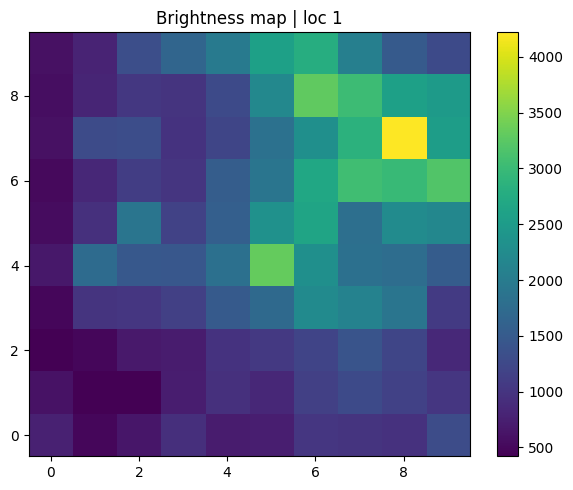

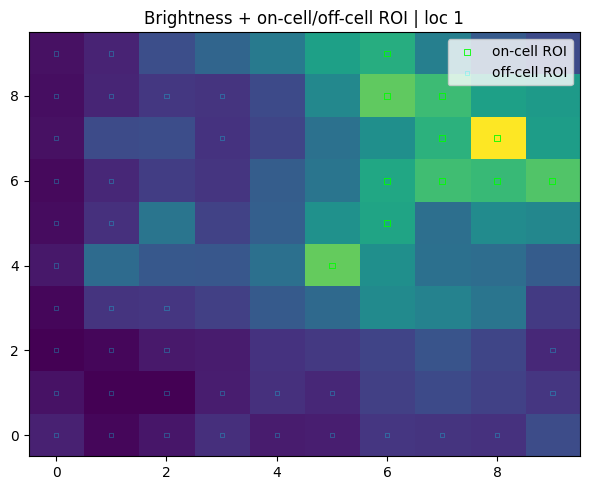

[roi-align] on_mask resized from (10, 10) -> (31, 31)
[roi-align] off_mask resized from (10, 10) -> (31, 31)


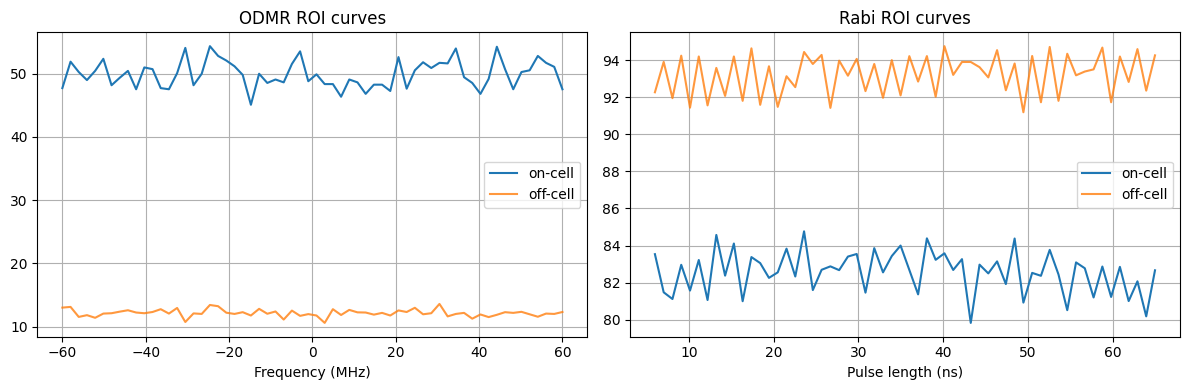

In [5]:

# =========================
# Block 1C: Brightness image + Fig.5a-style ROI overlay
# =========================

bright_odmr = brightness_map(odmr_arr)
on_mask, off_mask = make_on_off_masks(bright_odmr, on_pct=cfg.roi_percentile, off_pct=40.0)

save_map(bright_odmr, f"Brightness map | loc {demo_loc_id}", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_brightness.png"))
overlay_roi(
    bright_odmr,
    on_mask,
    off_mask,
    title=f"Brightness + on-cell/off-cell ROI | loc {demo_loc_id}",
    out_png=os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_brightness_roi_overlay.png")
)

# ROI curves for sanity check
rabi_on_mask = align_roi_mask_to_shape(on_mask, rabi_arr.shape[:2], mask_name="on_mask")
rabi_off_mask = align_roi_mask_to_shape(off_mask, rabi_arr.shape[:2], mask_name="off_mask")

odmr_on_curve, _ = extract_curve_from_stack(odmr_arr, on_mask)
odmr_off_curve, _ = extract_curve_from_stack(odmr_arr, off_mask)
rabi_on_curve, _ = extract_curve_from_stack(rabi_arr, rabi_on_mask)
rabi_off_curve, _ = extract_curve_from_stack(rabi_arr, rabi_off_mask)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(odmr_x_mhz, odmr_on_curve, label="on-cell")
plt.plot(odmr_x_mhz, odmr_off_curve, label="off-cell", alpha=0.8)
plt.title("ODMR ROI curves")
plt.xlabel("Frequency (MHz)")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(rabi_x_ns, rabi_on_curve, label="on-cell")
plt.plot(rabi_x_ns, rabi_off_curve, label="off-cell", alpha=0.8)
plt.title("Rabi ROI curves")
plt.xlabel("Pulse length (ns)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_roi_curves.png"), dpi=180)
plt.show()


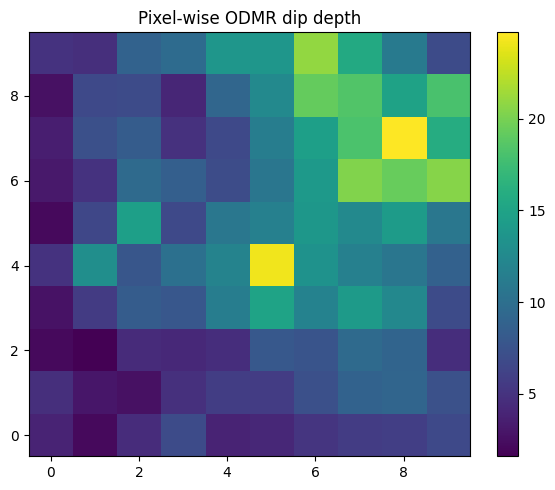

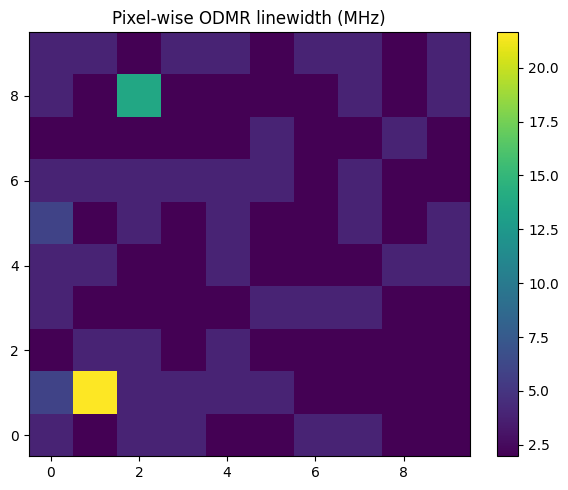

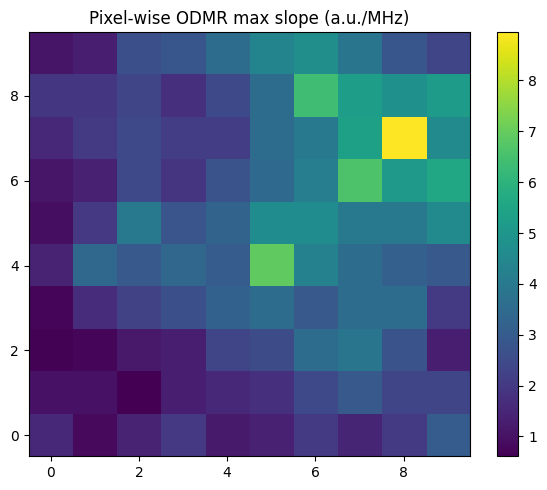

In [6]:

# =========================
# Block 1D: Pixel-wise ODMR maps
# =========================

odmr_counts_xys = extract_counts_xys(odmr_arr)   # (X,Y,S)
X, Y, S = odmr_counts_xys.shape

odmr_depth_map = np.zeros((X,Y), dtype=np.float32)
odmr_lw_map = np.zeros((X,Y), dtype=np.float32)
odmr_slope_map = np.zeros((X,Y), dtype=np.float32)

for i in range(X):
    for j in range(Y):
        m = odmr_metrics_raw(odmr_x_mhz, odmr_counts_xys[i,j,:])
        odmr_depth_map[i,j] = m["depth"]
        odmr_lw_map[i,j] = m["linewidth_MHz"]
        odmr_slope_map[i,j] = m["slope_per_MHz"]

save_map(odmr_depth_map, "Pixel-wise ODMR dip depth", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_odmr_depth.png"))
save_map(odmr_lw_map, "Pixel-wise ODMR linewidth (MHz)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_odmr_linewidth.png"))
save_map(odmr_slope_map, "Pixel-wise ODMR max slope (a.u./MHz)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_odmr_slope.png"))


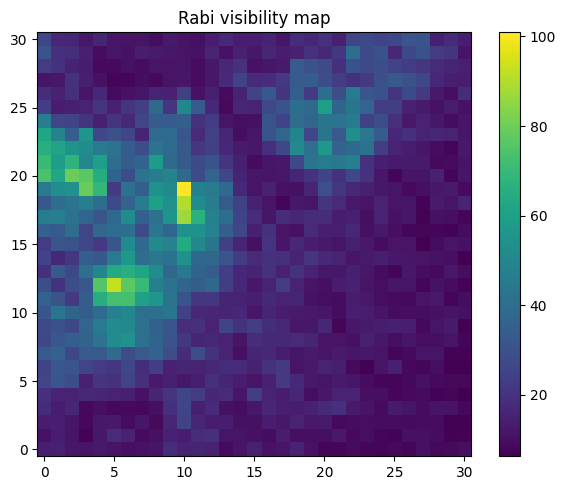

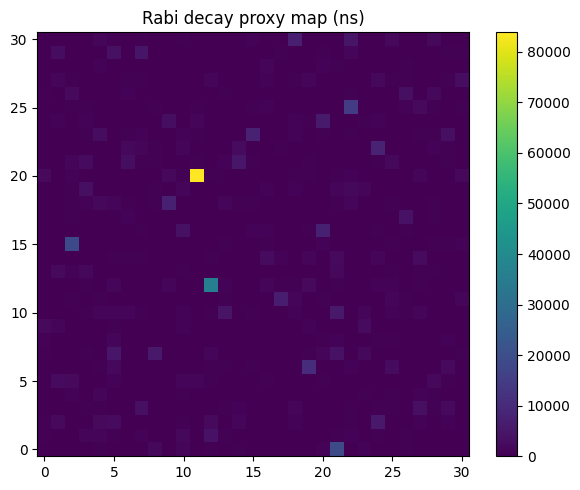

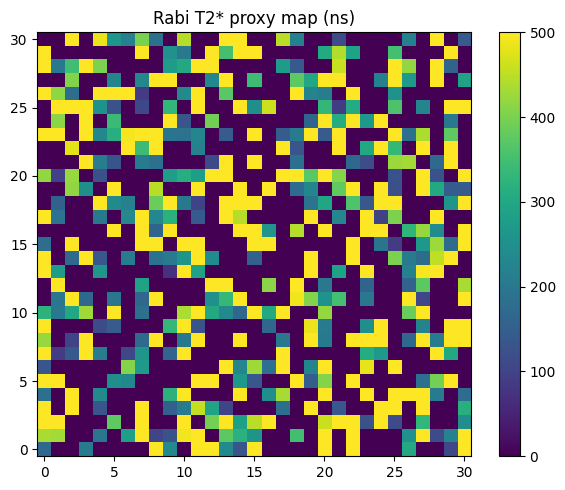

In [7]:

# =========================
# Block 1E: Rabi coherence proxy maps
# =========================

rabi_counts_xys = extract_counts_xys(rabi_arr)
Xr, Yr, Sr = rabi_counts_xys.shape

rabi_vis_map = np.zeros((Xr,Yr), dtype=np.float32)
rabi_decay_map = np.full((Xr,Yr), np.nan, dtype=np.float32)
rabi_t2_map = np.full((Xr,Yr), np.nan, dtype=np.float32)

for i in range(Xr):
    for j in range(Yr):
        y = rabi_counts_xys[i,j,:]
        rabi_vis_map[i,j] = rabi_visibility(y)
        rabi_decay_map[i,j] = decay_proxy_from_rabi(rabi_x_ns, y)
        y_norm = robust_normalize_curve(y)
        rabi_t2_map[i,j] = estimate_T2star_from_rabi_index(rabi_x_ns, y_norm)

save_map(rabi_vis_map, "Rabi visibility map", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_rabi_visibility.png"))
save_map(np.nan_to_num(rabi_decay_map, nan=0.0), "Rabi decay proxy map (ns)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_rabi_decay_proxy.png"))
save_map(np.nan_to_num(rabi_t2_map, nan=0.0), "Rabi T2* proxy map (ns)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_rabi_t2_proxy.png"))


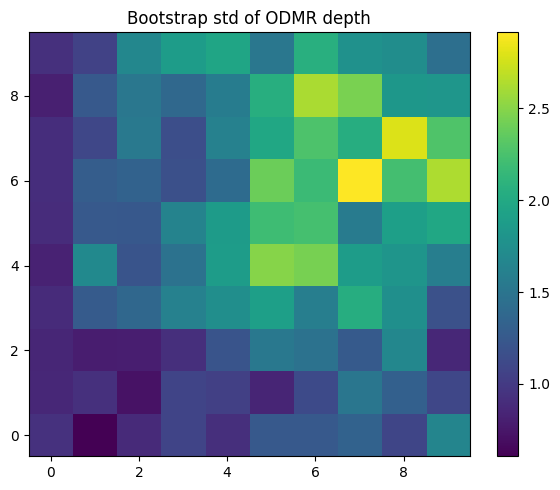

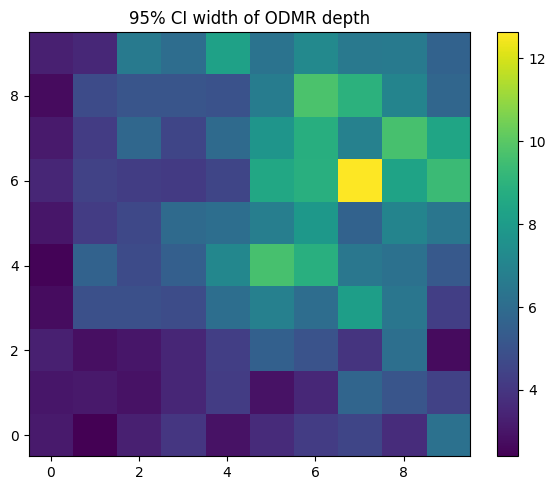

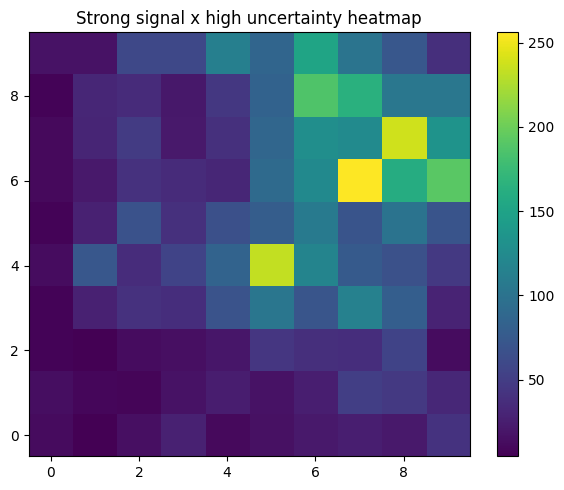

{
  "on_cell_depth_mean": 19.418182373046875,
  "on_cell_depth_ciwidth_mean": 9.003864288330078,
  "off_cell_depth_mean": 4.611111164093018,
  "off_cell_depth_ciwidth_mean": 3.6171536445617676
}


In [8]:

# =========================
# Block 1F: Photon bootstrap uncertainty maps
# =========================

# Bootstrap uses Poisson photon resampling on ODMR counts_xys.
boot_mean_depth, boot_std_depth, boot_low_depth, boot_high_depth = bootstrap_depth_ci_per_pixel(
    odmr_counts_xys, n_boot=40, seed=SEED
)

ci_width_depth = (boot_high_depth - boot_low_depth).astype(np.float32)
risk_map = odmr_depth_map * ci_width_depth  # strong signal but also high uncertainty

save_map(boot_std_depth, "Bootstrap std of ODMR depth", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_uncert_std_depth.png"))
save_map(ci_width_depth, "95% CI width of ODMR depth", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_uncert_ciwidth_depth.png"))
save_map(risk_map, "Strong signal x high uncertainty heatmap", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_signal_uncert_risk.png"))

roi_stats = {
    "on_cell_depth_mean": float(np.mean(odmr_depth_map[on_mask])),
    "on_cell_depth_ciwidth_mean": float(np.mean(ci_width_depth[on_mask])),
    "off_cell_depth_mean": float(np.mean(odmr_depth_map[off_mask])),
    "off_cell_depth_ciwidth_mean": float(np.mean(ci_width_depth[off_mask])),
}
print(json.dumps(roi_stats, indent=2))
save_json(os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_roi_uncertainty_stats.json"), roi_stats)


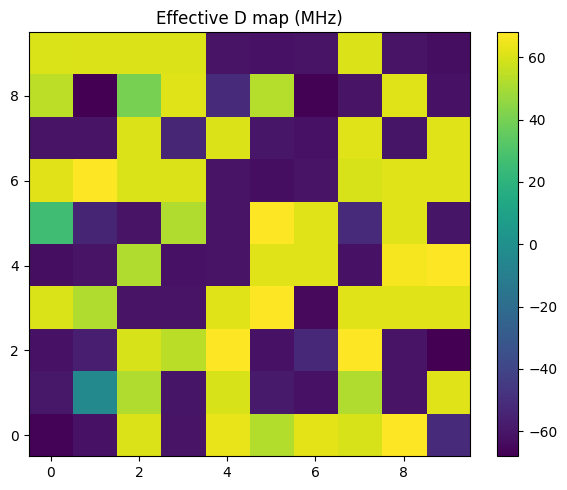

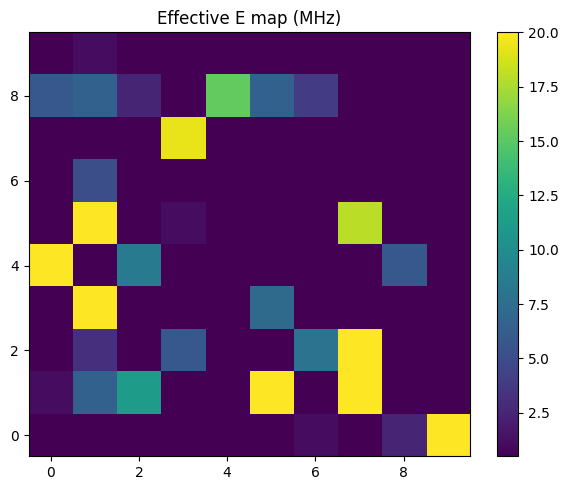

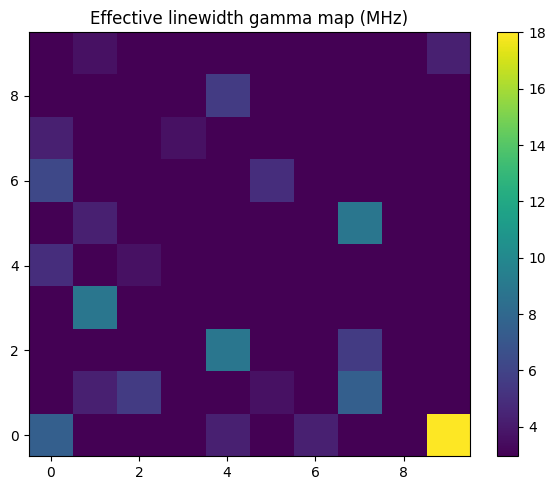

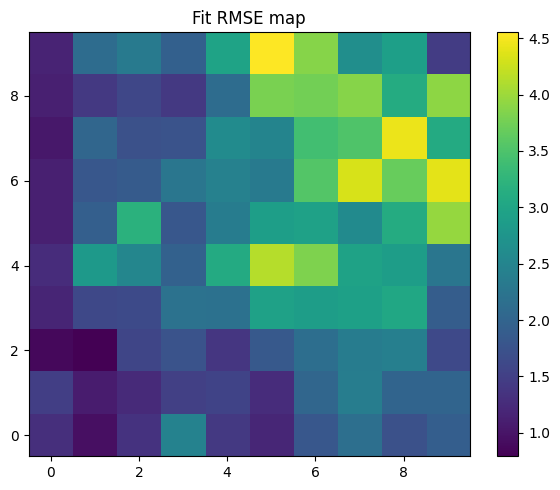

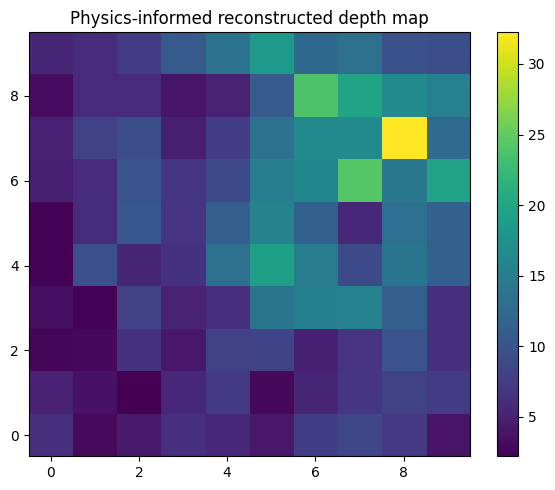

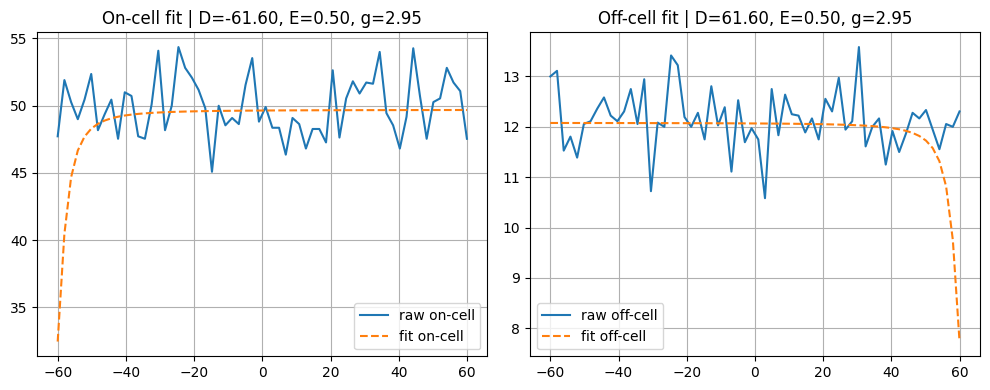

{
  "demo_loc_id": 1,
  "odmr_path": "fig_5/fig_5b/fig_5b_loc_1.npz",
  "rabi_path": "fig_5/fig_5c/fig_5c_loc_1.npz",
  "on_cell": {
    "D_MHz": -61.6,
    "E_MHz": 0.5,
    "gamma_MHz": 2.9508190155029297,
    "rmse": 3.1157380819251146
  },
  "off_cell": {
    "D_MHz": 61.6,
    "E_MHz": 0.5,
    "gamma_MHz": 2.9508190155029297,
    "rmse": 0.7079495735681534
  }
}


In [9]:

# =========================
# Block 1G: Physics-informed reconstruction (effective local Hamiltonian fit)
# =========================

D_map = np.full((X,Y), np.nan, dtype=np.float32)
E_map = np.full((X,Y), np.nan, dtype=np.float32)
Gamma_map = np.full((X,Y), np.nan, dtype=np.float32)
RMSE_map = np.full((X,Y), np.nan, dtype=np.float32)
Recon_depth_map = np.full((X,Y), np.nan, dtype=np.float32)

for i in range(X):
    for j in range(Y):
        fit = effective_two_lorentzian_fit(odmr_x_mhz, odmr_counts_xys[i,j,:])
        D_map[i,j] = fit["D_MHz"]
        E_map[i,j] = fit["E_MHz"]
        Gamma_map[i,j] = fit["gamma_MHz"]
        RMSE_map[i,j] = fit["rmse"]
        Recon_depth_map[i,j] = float(np.max(fit["pred"]) - np.min(fit["pred"]))

save_map(D_map, "Effective D map (MHz)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_D_map.png"))
save_map(E_map, "Effective E map (MHz)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_E_map.png"))
save_map(Gamma_map, "Effective linewidth gamma map (MHz)", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_gamma_map.png"))
save_map(RMSE_map, "Fit RMSE map", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_fit_rmse.png"))
save_map(Recon_depth_map, "Physics-informed reconstructed depth map", os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_reconstructed_depth.png"))

# raw vs reconstructed ROI example
fit_on = effective_two_lorentzian_fit(odmr_x_mhz, odmr_on_curve)
fit_off = effective_two_lorentzian_fit(odmr_x_mhz, odmr_off_curve)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(odmr_x_mhz, odmr_on_curve, label="raw on-cell")
plt.plot(odmr_x_mhz, fit_on["pred"], '--', label="fit on-cell")
plt.title(f"On-cell fit | D={fit_on['D_MHz']:.2f}, E={fit_on['E_MHz']:.2f}, g={fit_on['gamma_MHz']:.2f}")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(odmr_x_mhz, odmr_off_curve, label="raw off-cell")
plt.plot(odmr_x_mhz, fit_off["pred"], '--', label="fit off-cell")
plt.title(f"Off-cell fit | D={fit_off['D_MHz']:.2f}, E={fit_off['E_MHz']:.2f}, g={fit_off['gamma_MHz']:.2f}")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_roi_raw_vs_fit.png"), dpi=180)
plt.show()

summary = {
    "demo_loc_id": int(demo_loc_id),
    "odmr_path": odmr_path,
    "rabi_path": rabi_path,
    "on_cell": {
        "D_MHz": float(fit_on["D_MHz"]),
        "E_MHz": float(fit_on["E_MHz"]),
        "gamma_MHz": float(fit_on["gamma_MHz"]),
        "rmse": float(fit_on["rmse"]),
    },
    "off_cell": {
        "D_MHz": float(fit_off["D_MHz"]),
        "E_MHz": float(fit_off["E_MHz"]),
        "gamma_MHz": float(fit_off["gamma_MHz"]),
        "rmse": float(fit_off["rmse"]),
    }
}
print(json.dumps(summary, indent=2))
save_json(os.path.join(DEMO_DIR, f"loc_{demo_loc_id:03d}_physics_fit_summary.json"), summary)


[GAN] ep 20/200 | loss_d=1.2576 loss_g=0.6442
[GAN] ep 40/200 | loss_d=1.2355 loss_g=0.7554
[GAN] ep 60/200 | loss_d=1.0790 loss_g=0.9977
[GAN] ep 80/200 | loss_d=0.8496 loss_g=1.2505
[GAN] ep 100/200 | loss_d=0.8852 loss_g=1.3612
[GAN] ep 120/200 | loss_d=0.6194 loss_g=1.7129
[GAN] ep 140/200 | loss_d=1.0341 loss_g=1.3422
[GAN] ep 160/200 | loss_d=0.4301 loss_g=1.9441
[GAN] ep 180/200 | loss_d=0.6264 loss_g=1.7183
[GAN] ep 200/200 | loss_d=0.6243 loss_g=1.6111
[DDPM] ep 20/120 | loss=1.02565
[DDPM] ep 40/120 | loss=0.94042
[DDPM] ep 60/120 | loss=0.93568
[DDPM] ep 80/120 | loss=0.95012
[DDPM] ep 100/120 | loss=0.93414
[DDPM] ep 120/120 | loss=0.89921
[T2NN] ep 20/120 | loss=6878.52441
[T2NN] ep 40/120 | loss=11758.89648
[T2NN] ep 60/120 | loss=10744.82227
[T2NN] ep 80/120 | loss=7295.21777
[T2NN] ep 100/120 | loss=9188.55859
[T2NN] ep 120/120 | loss=12479.85352
Saved models + trends to artifacts/run_20260324_131950


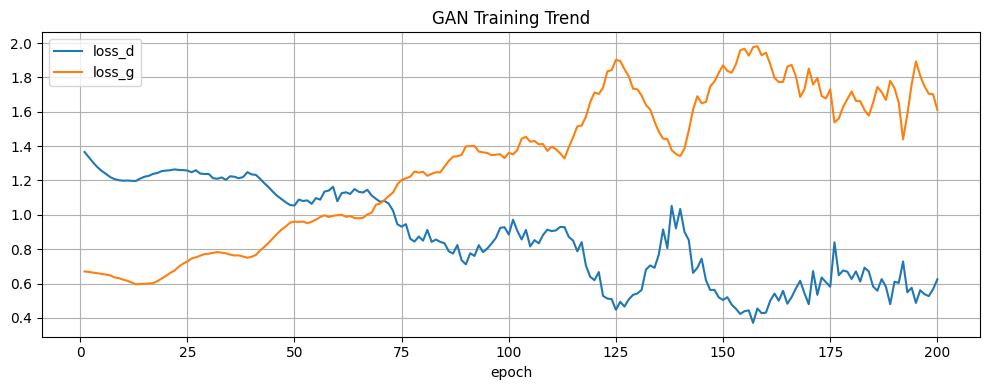

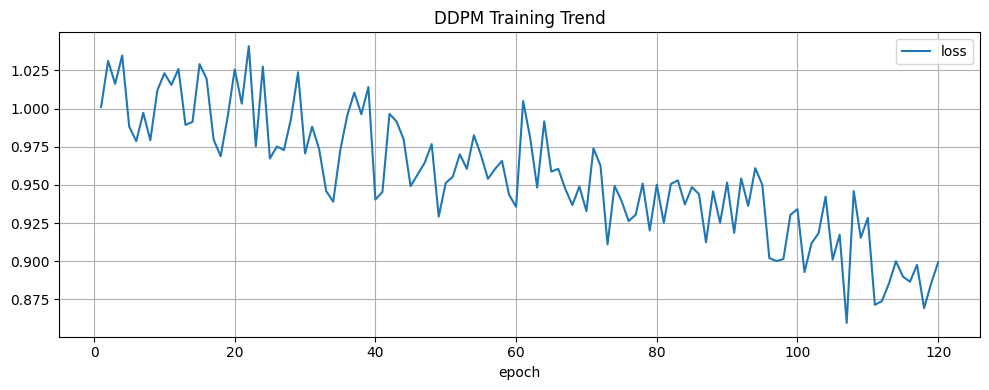

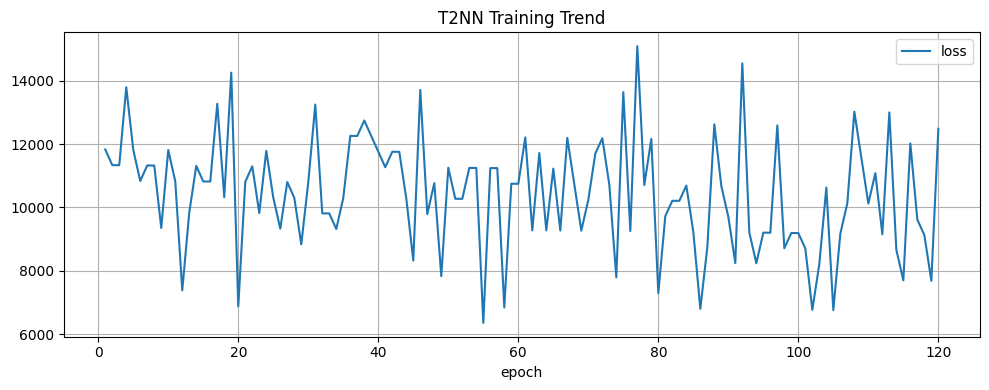

In [10]:
# =========================
# Block 2: Train (GAN + DDPM + T2 Predictor) + Save
# =========================

# Models
gen = RabiGenerator(z_dim=cfg.z_dim, cond_dim=COND_DIM, out_len=RABI_LEN).to(DEVICE)
dis = RabiDiscriminator(cond_dim=COND_DIM, in_len=RABI_LEN).to(DEVICE)

denoiser = Denoiser1D(x_len=RABI_LEN, cond_dim=COND_DIM).to(DEVICE)
ddpm = ConditionalDDPM(denoiser, T=200, device=DEVICE)

t2_nn = T2PredictorNN(x_len=RABI_LEN).to(DEVICE)

# Optims
opt_g = optim.Adam(gen.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
opt_d = optim.Adam(dis.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
opt_ddpm = optim.Adam(denoiser.parameters(), lr=1e-4)
opt_t2 = optim.Adam(t2_nn.parameters(), lr=1e-4)

bce = nn.BCELoss()
mse = nn.MSELoss()

N = X_rabi.size(0)

def batch_indices(bs):
    return torch.randint(0, N, (bs,), device=DEVICE)

# ---- 1) GAN training ----
tr_gan = []
for ep in range(1, cfg.epochs_gan+1):
    idx = batch_indices(cfg.batch_size)
    real = X_rabi[idx]
    cond = C_cond[idx]

    # train D
    z = torch.randn(cfg.batch_size, cfg.z_dim, device=DEVICE)
    fake = gen(z, cond).detach()

    lbl_real = torch.ones(cfg.batch_size, device=DEVICE)
    lbl_fake = torch.zeros(cfg.batch_size, device=DEVICE)

    out_real = dis(real, cond).view(-1)
    out_fake = dis(fake, cond).view(-1)

    loss_d = bce(out_real, lbl_real) + bce(out_fake, lbl_fake)
    opt_d.zero_grad(); loss_d.backward(); opt_d.step()

    # train G
    z = torch.randn(cfg.batch_size, cfg.z_dim, device=DEVICE)
    fake2 = gen(z, cond)
    out_fake2 = dis(fake2, cond).view(-1)
    loss_g = bce(out_fake2, lbl_real)
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()

    tr_gan.append({"epoch": ep, "loss_d": float(loss_d.item()), "loss_g": float(loss_g.item())})
    if ep % 20 == 0:
        print(f"[GAN] ep {ep}/{cfg.epochs_gan} | loss_d={loss_d.item():.4f} loss_g={loss_g.item():.4f}")

# ---- 2) DDPM training (refine generator outputs toward real distribution) ----
tr_ddpm = []
for ep in range(1, cfg.epochs_ddpm+1):
    idx = batch_indices(cfg.batch_size)
    real = X_rabi[idx]
    cond = C_cond[idx]

    loss = ddpm.loss(real, cond)  # diffusion learns to denoise real samples conditioned on ODMR-features
    opt_ddpm.zero_grad(); loss.backward(); opt_ddpm.step()

    tr_ddpm.append({"epoch": ep, "loss": float(loss.item())})
    if ep % 20 == 0:
        print(f"[DDPM] ep {ep}/{cfg.epochs_ddpm} | loss={loss.item():.5f}")

# ---- 3) T2 predictor training ----
tr_t2 = []
for ep in range(1, cfg.epochs_t2+1):
    idx = batch_indices(cfg.batch_size)
    real = X_rabi[idx]
    y = y_t2[idx]

    pred = t2_nn(real)
    loss = mse(pred, y)
    opt_t2.zero_grad(); loss.backward(); opt_t2.step()

    tr_t2.append({"epoch": ep, "loss": float(loss.item())})
    if ep % 20 == 0:
        print(f"[T2NN] ep {ep}/{cfg.epochs_t2} | loss={loss.item():.5f}")

# ---- Save models ----
torch.save(gen.state_dict(), os.path.join(RUN_DIR, "gen.pt"))
torch.save(dis.state_dict(), os.path.join(RUN_DIR, "dis.pt"))
torch.save(denoiser.state_dict(), os.path.join(RUN_DIR, "denoiser.pt"))
torch.save(t2_nn.state_dict(), os.path.join(RUN_DIR, "t2_nn.pt"))

save_json(os.path.join(RUN_DIR, "trend_gan.json"), tr_gan)
save_json(os.path.join(RUN_DIR, "trend_ddpm.json"), tr_ddpm)
save_json(os.path.join(RUN_DIR, "trend_t2.json"), tr_t2)

print("Saved models + trends to", RUN_DIR)

# ---- Trend plots ----
save_trend_plot(tr_gan, ["loss_d","loss_g"], "GAN Training Trend", os.path.join(RUN_DIR, "trend_gan.png"))
save_trend_plot(tr_ddpm, ["loss"], "DDPM Training Trend", os.path.join(RUN_DIR, "trend_ddpm.png"))
save_trend_plot(tr_t2, ["loss"], "T2NN Training Trend", os.path.join(RUN_DIR, "trend_t2.png"))


[T2*(proxy, ns)] real=2.30 | gan=0.68 | refined=0.12


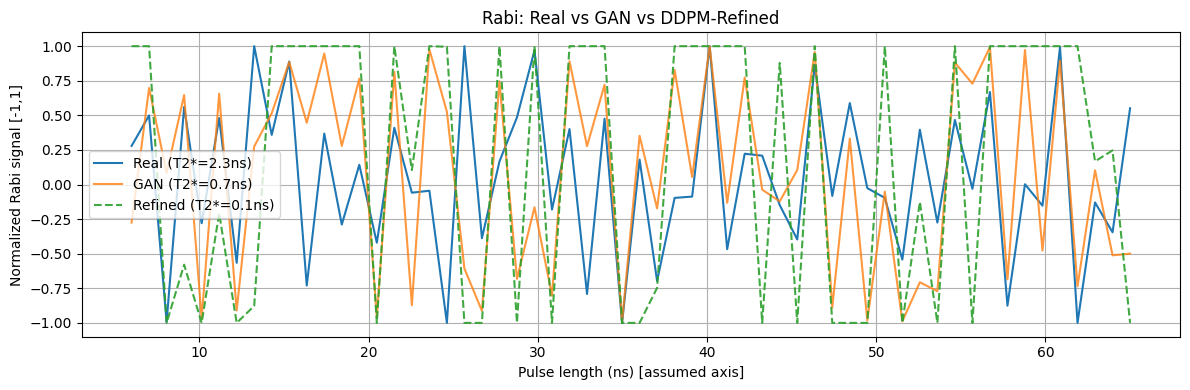

ODMR-condition features: [ 1.041896    0.06451613  0.9476303  -0.06558361  0.57530147] (depth, lw_frac, slope, mean, std)


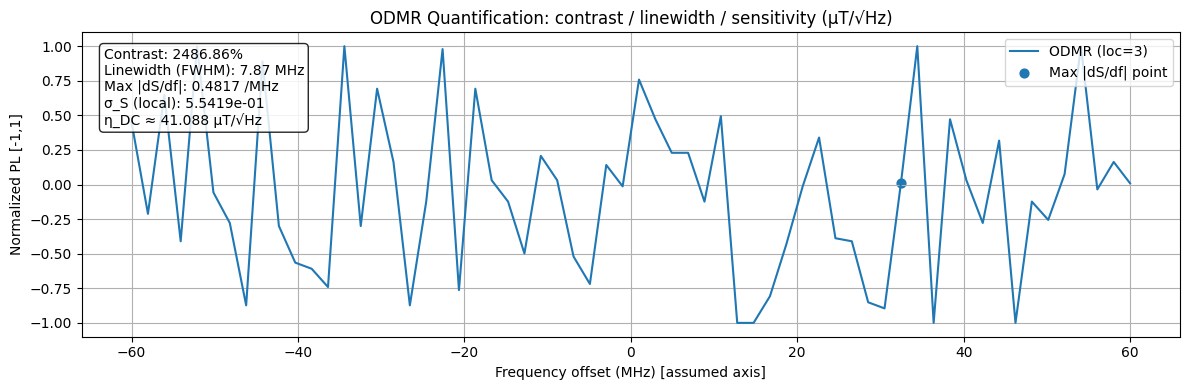

[ODMR Quantification] {'contrast': 24.86863527851836, 'linewidth_MHz': 7.868851661682129, 'slope_per_MHz': 0.48171186447143555, 'eta_uT_per_sqrtHz': 41.08804480830422}


In [11]:
# =========================
# Block 3: Test + Visualization
# =========================

gen.eval(); denoiser.eval(); t2_nn.eval()

# 임의 샘플 선택
i = np.random.randint(0, N)
cond = C_cond[i:i+1]
real = X_rabi[i:i+1]

# GAN 생성
z = torch.randn(1, cfg.z_dim, device=DEVICE)
gan_curve = gen(z, cond)

# DDPM 정제 (GAN 출력을 초기값으로 사용)
ref_curve = ddpm.sample_from(gan_curve, cond, cfg_scale=1.8)

# T2* 예측
with torch.no_grad():
    t2_real = float(t2_nn(real).item())
    t2_gan  = float(t2_nn(gan_curve).item())
    t2_ref  = float(t2_nn(ref_curve).item())

print(f"[T2*(proxy, ns)] real={t2_real:.2f} | gan={t2_gan:.2f} | refined={t2_ref:.2f}")

# plot
real_np = real.squeeze().detach().cpu().numpy()
gan_np  = gan_curve.squeeze().detach().cpu().numpy()
ref_np  = ref_curve.squeeze().detach().cpu().numpy()

plt.figure(figsize=(12,4))
plt.plot(rabi_x_ns, real_np, label=f"Real (T2*={t2_real:.1f}ns)")
plt.plot(rabi_x_ns, gan_np,  label=f"GAN (T2*={t2_gan:.1f}ns)", alpha=0.8)
plt.plot(rabi_x_ns, ref_np,  label=f"Refined (T2*={t2_ref:.1f}ns)", alpha=0.9, linestyle="--")
plt.xlabel("Pulse length (ns) [assumed axis]")
plt.ylabel("Normalized Rabi signal [-1,1]")
plt.title("Rabi: Real vs GAN vs DDPM-Refined")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "test_rabi_real_gan_refined.png"), dpi=160)
plt.show()

# Condition(ODMR feature)도 같이 보여주기
cond_np = cond.squeeze().detach().cpu().numpy()
print("ODMR-condition features:", cond_np, "(depth, lw_frac, slope, mean, std)")
# =========================
# + ODMR Visualization WITH Quantification (contrast/linewidth/sensitivity)
# =========================

# 선택된 샘플 i의 ODMR curve 가져오기 (Block1에서 dataset 리스트가 있음)
odmr_curve = dataset[i]["odmr_curve"]  # normalized [-1,1]
odmr_q = odmr_sensitivity_uT_per_sqrtHz(
    odmr_x_mhz,              # Block1에서 만든 axis (assumed)
    odmr_curve,
    gamma_Hz_per_T=28e9,
    photon_noise_floor=8e-4,
    local_win=10
)

# plot ODMR + quant box
plt.figure(figsize=(12,4))
plt.plot(odmr_x_mhz, odmr_curve, label=f"ODMR (loc={dataset[i]['loc_id']})")
plt.xlabel("Frequency offset (MHz) [assumed axis]")
plt.ylabel("Normalized PL [-1,1]")
plt.title("ODMR Quantification: contrast / linewidth / sensitivity (µT/√Hz)")
plt.grid(True)

# annotate key point (max slope)
idx = odmr_q["idx_max_slope"]
plt.scatter([odmr_x_mhz[idx]], [odmr_curve[idx]], s=40, label="Max |dS/df| point")

text = (
    f"Contrast: {odmr_q['contrast']*100:.2f}%\n"
    f"Linewidth (FWHM): {odmr_q['linewidth_MHz']:.2f} MHz\n"
    f"Max |dS/df|: {odmr_q['slope_per_MHz']:.4f} /MHz\n"
    f"σ_S (local): {odmr_q['sigma_S']:.4e}\n"
    f"η_DC ≈ {odmr_q['eta_uT_per_sqrtHz']:.3f} µT/√Hz"
)

plt.gca().text(
    0.02, 0.95, text,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "test_odmr_quantified.png"), dpi=160)
plt.show()

print("[ODMR Quantification]", {k: odmr_q[k] for k in ["contrast","linewidth_MHz","slope_per_MHz","eta_uT_per_sqrtHz"]})


In [ ]:

# =========================
# Block 1H: Advanced physics-aware demo
#   - powder orientation ensemble
#   - global/shared parameter fit
#   - OADF timing/readout contrast
# =========================

ADV_DIR = os.path.join(DEMO_DIR, "advanced")
os.makedirs(ADV_DIR, exist_ok=True)
print("ADV_DIR:", ADV_DIR)

try:
    from scipy.optimize import curve_fit
    SCIPY_OK = True
except Exception as _e:
    print("[warn] scipy.optimize not available -> using coarse grid only:", _e)
    SCIPY_OK = False


# Ensure ROI ODMR curves exist even if Block 1C was not re-run
if "odmr_on_curve" not in globals() or "odmr_off_curve" not in globals():
    print("[advanced demo] ROI ODMR curves not found in memory -> rebuilding from current stacks/masks.")
    if "bright_odmr" not in globals():
        bright_odmr = brightness_map(odmr_arr)
    if "on_mask" not in globals() or "off_mask" not in globals():
        on_mask, off_mask = make_on_off_masks(bright_odmr, on_pct=cfg.roi_percentile, off_pct=40.0)
    odmr_on_curve, _ = extract_curve_from_stack(odmr_arr, on_mask)
    odmr_off_curve, _ = extract_curve_from_stack(odmr_arr, off_mask)

def lorentz_unit(x, x0, gamma):
    g = max(float(gamma), 1e-6)
    return 1.0 / (1.0 + ((x - x0) / g) ** 2)

def powder_two_lorentzian_model(x, D_MHz, E_MHz, gamma_MHz, orient_sigma=0.12, amp=1.0, baseline=1.0, n_orient=31):
    """
    Physics-inspired orientation-ensemble surrogate.
    Not a full Hamiltonian powder integral, but averages over effective orientation perturbations.
    """
    x = np.asarray(x, dtype=np.float32)
    thetas = np.linspace(0.0, np.pi, int(n_orient), dtype=np.float32)
    weights = np.sin(thetas)
    weights = weights / np.maximum(weights.sum(), 1e-8)

    y = np.zeros_like(x, dtype=np.float32)
    for th, w in zip(thetas, weights):
        c = float(np.cos(th))
        # orientation spread perturbs splitting + linewidth
        d_shift = orient_sigma * 0.20 * D_MHz * (0.5 * (3.0 * c * c - 1.0))
        e_eff = max(0.0, E_MHz * (1.0 + orient_sigma * (1.0 - c * c)))
        g_eff = max(1e-3, gamma_MHz * (1.0 + 0.35 * orient_sigma * abs(c)))
        c1 = (D_MHz + d_shift) - e_eff
        c2 = (D_MHz + d_shift) + e_eff
        dip = lorentz_unit(x, c1, g_eff) + lorentz_unit(x, c2, g_eff)
        y += w * (baseline - amp * dip)
    return y.astype(np.float32)

def _powder_curvefit_wrapper(x, D, E, gamma, orient_sigma, amp, baseline):
    return powder_two_lorentzian_model(x, D, E, gamma, orient_sigma, amp, baseline, n_orient=41)

def powder_fit_roi(x, y):
    y = np.asarray(y, dtype=np.float32)
    y_n = robust_normalize_curve(y)
    ef = effective_two_lorentzian_fit(x, y_n)
    p0 = [
        float(ef["D_MHz"]),
        max(0.1, float(ef["E_MHz"])),
        max(0.2, float(ef["gamma_MHz"])),
        0.12,
        max(0.02, 0.5 * float(np.max(y_n) - np.min(y_n))),
        float(np.median(y_n)),
    ]
    bounds = ([x.min(), 0.0, 0.05, 0.0, 0.0, -2.0],
              [x.max(), max(1.0, (x.max()-x.min())/2), max(20.0, (x.max()-x.min())/2), 1.0, 3.0, 3.0])

    if SCIPY_OK:
        try:
            popt, pcov = curve_fit(_powder_curvefit_wrapper, x, y_n, p0=p0, bounds=bounds, maxfev=20000)
            pred = _powder_curvefit_wrapper(x, *popt)
            perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
            return {
                "D_MHz": float(popt[0]), "E_MHz": float(popt[1]), "gamma_MHz": float(popt[2]),
                "orient_sigma": float(popt[3]), "amp": float(popt[4]), "baseline": float(popt[5]),
                "rmse": float(np.sqrt(np.mean((pred - y_n) ** 2))),
                "pred": pred.astype(np.float32), "y_norm": y_n.astype(np.float32),
                "stderr": perr.tolist(),
            }
        except Exception as e:
            print("[warn] scipy powder fit failed -> coarse fit:", e)

    # fallback coarse grid
    best = None
    D0, E0, G0 = p0[:3]
    for D in np.linspace(max(x.min(), D0-20), min(x.max(), D0+20), 25):
        for E in np.linspace(max(0.0, E0*0.3), max(1.0, E0*2.0+0.2), 21):
            for G in np.linspace(max(0.1, G0*0.5), max(0.5, G0*2.0+0.2), 16):
                for S in np.linspace(0.0, 0.45, 10):
                    basis = powder_two_lorentzian_model(x, D, E, G, S, amp=1.0, baseline=0.0, n_orient=25)
                    A = np.vstack([basis, np.ones_like(basis)]).T
                    coef, *_ = np.linalg.lstsq(A, y_n, rcond=None)
                    amp, base = float(coef[0]), float(coef[1])
                    pred = amp * basis + base
                    rmse = float(np.sqrt(np.mean((pred - y_n) ** 2)))
                    if best is None or rmse < best["rmse"]:
                        best = {"D_MHz": float(D), "E_MHz": float(E), "gamma_MHz": float(G), "orient_sigma": float(S),
                                "amp": float(amp), "baseline": float(base), "pred": pred.astype(np.float32),
                                "y_norm": y_n.astype(np.float32), "rmse": rmse, "stderr": None}
    return best

# ROI powder fit: on / off cell
pow_on = powder_fit_roi(odmr_x_mhz, odmr_on_curve)
pow_off = powder_fit_roi(odmr_x_mhz, odmr_off_curve)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(odmr_x_mhz, pow_on["y_norm"], label="on-cell norm")
plt.plot(odmr_x_mhz, pow_on["pred"], '--', label="powder fit")
plt.title(f'Powder fit on-cell | D={pow_on["D_MHz"]:.2f}, E={pow_on["E_MHz"]:.2f}, g={pow_on["gamma_MHz"]:.2f}, s={pow_on["orient_sigma"]:.2f}')
plt.xlabel("Frequency (MHz)"); plt.grid(True); plt.legend()
plt.subplot(1,2,2)
plt.plot(odmr_x_mhz, pow_off["y_norm"], label="off-cell norm")
plt.plot(odmr_x_mhz, pow_off["pred"], '--', label="powder fit")
plt.title(f'Powder fit off-cell | D={pow_off["D_MHz"]:.2f}, E={pow_off["E_MHz"]:.2f}, g={pow_off["gamma_MHz"]:.2f}, s={pow_off["orient_sigma"]:.2f}')
plt.xlabel("Frequency (MHz)"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_powder_roi_fits.png"), dpi=150, bbox_inches="tight")
plt.show()

save_json(os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_powder_roi_fit.json"), {
    "on_cell": {k:v for k,v in pow_on.items() if k not in ["pred","y_norm"]},
    "off_cell": {k:v for k,v in pow_off.items() if k not in ["pred","y_norm"]},
})

# -------------------------
# Shared/global parameter fit
# -------------------------
bright_flat = bright_odmr.reshape(-1)
pix_order = np.argsort(bright_flat)[::-1]
top_n = int(min(96, max(24, 0.03 * bright_flat.size)))
sel = pix_order[:top_n]

stack_top = []
coords_top = []
for idx in sel:
    i = idx // Y
    j = idx % Y
    cur = robust_normalize_curve(odmr_counts_xys[i,j,:])
    if np.std(cur) > 1e-6:
        stack_top.append(cur)
        coords_top.append((int(i), int(j)))
stack_top = np.asarray(stack_top, dtype=np.float32)
shared_curve = np.median(stack_top, axis=0)
shared_fit = powder_fit_roi(odmr_x_mhz, shared_curve)

plt.figure(figsize=(6,4))
plt.plot(odmr_x_mhz, robust_normalize_curve(shared_curve), label="median top-pixel curve")
plt.plot(odmr_x_mhz, shared_fit["pred"], '--', label="shared powder fit")
plt.title(f'Shared fit | n={len(stack_top)} top bright pixels')
plt.xlabel("Frequency (MHz)"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_shared_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

shared_D = float(shared_fit["D_MHz"])
shared_gamma = float(shared_fit["gamma_MHz"])
shared_sigma = float(shared_fit["orient_sigma"])

shared_E_map = np.full((X,Y), np.nan, dtype=np.float32)
shared_amp_map = np.full((X,Y), np.nan, dtype=np.float32)
shared_rmse_map = np.full((X,Y), np.nan, dtype=np.float32)
shared_recon_map = np.full((X,Y), np.nan, dtype=np.float32)

e_grid = np.linspace(max(0.0, shared_fit["E_MHz"]*0.25), max(1.0, shared_fit["E_MHz"]*2.0+0.2), 26)
mask_fit = bright_odmr >= np.percentile(bright_odmr, 60.0)

basis_cache = {}
for E_try in e_grid:
    basis_cache[float(E_try)] = powder_two_lorentzian_model(
        odmr_x_mhz, shared_D, float(E_try), shared_gamma, shared_sigma, amp=1.0, baseline=0.0, n_orient=31
    )

for i in range(X):
    for j in range(Y):
        if not mask_fit[i,j]:
            continue
        y = robust_normalize_curve(odmr_counts_xys[i,j,:])
        best = None
        for E_try in e_grid:
            basis = basis_cache[float(E_try)]
            A = np.vstack([basis, np.ones_like(basis)]).T
            coef, *_ = np.linalg.lstsq(A, y, rcond=None)
            amp, base = float(coef[0]), float(coef[1])
            pred = amp * basis + base
            rmse = float(np.sqrt(np.mean((pred - y) ** 2)))
            if best is None or rmse < best[0]:
                best = (rmse, float(E_try), amp, pred)
        shared_rmse_map[i,j] = best[0]
        shared_E_map[i,j] = best[1]
        shared_amp_map[i,j] = best[2]
        shared_recon_map[i,j] = float(np.max(best[3]) - np.min(best[3]))

save_map(shared_E_map, "Shared-fit local E map (MHz)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_shared_E_map.png"))
save_map(shared_amp_map, "Shared-fit local ODMR amplitude map", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_shared_amp_map.png"))
save_map(shared_rmse_map, "Shared-fit RMSE map", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_shared_rmse_map.png"))
save_map(shared_recon_map, "Shared-fit reconstructed dip depth map", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_shared_recon_depth_map.png"))

save_json(os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_shared_fit.json"), {
    "shared_D_MHz": shared_D,
    "shared_gamma_MHz": shared_gamma,
    "shared_orient_sigma": shared_sigma,
    "n_top_pixels": int(len(stack_top)),
})

# -------------------------
# OADF timing / readout contrast simulator
# -------------------------
def oadf_contrast_from_maps(depth, t2_ns, readout_ns, temperature_mode="cryo"):
    depth = np.asarray(depth, dtype=np.float32)
    t2_ns = np.asarray(t2_ns, dtype=np.float32)
    readout_ns = np.asarray(readout_ns, dtype=np.float32)
    t2_eff = np.maximum(np.nan_to_num(t2_ns, nan=np.nanmedian(np.nan_to_num(t2_ns, nan=50.0))), 1.0)
    if temperature_mode == "cryo":
        tau_df = 220.0
        kappa = 1.0
    else:
        tau_df = 75.0
        kappa = 0.55
    temporal = (1.0 - np.exp(-readout_ns / tau_df)) * np.exp(-readout_ns / (2.5 * tau_df))
    coherence = np.exp(-readout_ns / np.maximum(2.0 * t2_eff, 1.0))
    c = kappa * depth * temporal * coherence
    return np.maximum(c, 0.0).astype(np.float32)

def oadf_snr_from_contrast(contrast, photons):
    photons = np.maximum(np.asarray(photons, dtype=np.float32), 1.0)
    return (contrast * np.sqrt(photons)).astype(np.float32)

photon_map = np.maximum(bright_odmr.astype(np.float32), 1.0)
oadf_target_xy = tuple(map(int, odmr_depth_map.shape))
rabi_t2_for_oadf = align_numeric_map_to_shape(rabi_t2_map, oadf_target_xy, map_name="rabi_t2_map")
photon_map = align_numeric_map_to_shape(photon_map, oadf_target_xy, map_name="photon_map")
readout_grid_ns = np.linspace(20.0, 400.0, 40, dtype=np.float32)
best_cryo_contrast = np.full(oadf_target_xy, -np.inf, dtype=np.float32)
best_cryo_snr = np.full(oadf_target_xy, -np.inf, dtype=np.float32)
best_cryo_t = np.zeros(oadf_target_xy, dtype=np.float32)
best_room_contrast = np.full(oadf_target_xy, -np.inf, dtype=np.float32)
best_room_snr = np.full(oadf_target_xy, -np.inf, dtype=np.float32)
best_room_t = np.zeros(oadf_target_xy, dtype=np.float32)

for t in readout_grid_ns:
    t_map = np.full(oadf_target_xy, float(t), dtype=np.float32)
    c_cryo = oadf_contrast_from_maps(odmr_depth_map, rabi_t2_for_oadf, t_map, "cryo")
    s_cryo = oadf_snr_from_contrast(c_cryo, photon_map)
    upd = s_cryo > best_cryo_snr
    best_cryo_snr[upd] = s_cryo[upd]
    best_cryo_contrast[upd] = c_cryo[upd]
    best_cryo_t[upd] = t

    c_room = oadf_contrast_from_maps(odmr_depth_map, rabi_t2_for_oadf, t_map, "room")
    s_room = oadf_snr_from_contrast(c_room, photon_map)
    upd = s_room > best_room_snr
    best_room_snr[upd] = s_room[upd]
    best_room_contrast[upd] = c_room[upd]
    best_room_t[upd] = t

save_map(best_cryo_contrast, "Best OADF contrast map (cryo proxy)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_cryo_contrast.png"))
save_map(best_cryo_snr, "Best OADF SNR map (cryo proxy)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_cryo_snr.png"))
save_map(best_cryo_t, "Optimal OADF readout window (cryo proxy, ns)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_cryo_topt.png"))
save_map(best_room_contrast, "Best OADF contrast map (room-T proxy)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_room_contrast.png"))
save_map(best_room_snr, "Best OADF SNR map (room-T proxy)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_room_snr.png"))
save_map(best_room_t, "Optimal OADF readout window (room-T proxy, ns)", os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_room_topt.png"))

# ROI timing curves
roi_readout = np.linspace(10.0, 450.0, 100, dtype=np.float32)
rabi_on_mask = align_roi_mask_to_shape(on_mask, rabi_t2_map.shape, mask_name="on_mask")
rabi_off_mask = align_roi_mask_to_shape(off_mask, rabi_t2_map.shape, mask_name="off_mask")
on_t2 = np.nanmedian(rabi_t2_map[rabi_on_mask]) if np.any(rabi_on_mask) else np.nanmedian(rabi_t2_map)
off_t2 = np.nanmedian(rabi_t2_map[rabi_off_mask]) if np.any(rabi_off_mask) else np.nanmedian(rabi_t2_map)
on_depth = np.nanmean(odmr_depth_map[on_mask]) if np.any(on_mask) else np.nanmean(odmr_depth_map)
off_depth = np.nanmean(odmr_depth_map[off_mask]) if np.any(off_mask) else np.nanmean(odmr_depth_map)
on_ph = np.nanmean(photon_map[on_mask]) if np.any(on_mask) else np.nanmean(photon_map)
off_ph = np.nanmean(photon_map[off_mask]) if np.any(off_mask) else np.nanmean(photon_map)

on_cryo = oadf_contrast_from_maps(on_depth, on_t2, roi_readout, "cryo")
off_cryo = oadf_contrast_from_maps(off_depth, off_t2, roi_readout, "cryo")
on_room = oadf_contrast_from_maps(on_depth, on_t2, roi_readout, "room")
off_room = oadf_contrast_from_maps(off_depth, off_t2, roi_readout, "room")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(roi_readout, on_cryo, label="on-cell cryo")
plt.plot(roi_readout, off_cryo, label="off-cell cryo")
plt.plot(roi_readout, on_room, label="on-cell room")
plt.plot(roi_readout, off_room, label="off-cell room")
plt.xlabel("Readout window (ns)")
plt.ylabel("Predicted OADF contrast (a.u.)")
plt.title("OADF timing contrast curves")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(roi_readout, oadf_snr_from_contrast(on_cryo, on_ph), label="on-cell cryo")
plt.plot(roi_readout, oadf_snr_from_contrast(off_cryo, off_ph), label="off-cell cryo")
plt.plot(roi_readout, oadf_snr_from_contrast(on_room, on_ph), label="on-cell room")
plt.plot(roi_readout, oadf_snr_from_contrast(off_room, off_ph), label="off-cell room")
plt.xlabel("Readout window (ns)")
plt.ylabel("Predicted OADF SNR (a.u.)")
plt.title("OADF timing SNR curves")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_roi_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

save_json(os.path.join(ADV_DIR, f"loc_{demo_loc_id:03d}_oadf_summary.json"), {
    "on_cell": {
        "t2_proxy_ns": float(on_t2),
        "depth": float(on_depth),
        "photon_mean": float(on_ph),
        "best_cryo_readout_ns": float(roi_readout[np.argmax(oadf_snr_from_contrast(on_cryo, on_ph))]),
        "best_room_readout_ns": float(roi_readout[np.argmax(oadf_snr_from_contrast(on_room, on_ph))]),
    },
    "off_cell": {
        "t2_proxy_ns": float(off_t2),
        "depth": float(off_depth),
        "photon_mean": float(off_ph),
        "best_cryo_readout_ns": float(roi_readout[np.argmax(oadf_snr_from_contrast(off_cryo, off_ph))]),
        "best_room_readout_ns": float(roi_readout[np.argmax(oadf_snr_from_contrast(off_room, off_ph))]),
    },
    "note": "OADF section is a physics-inspired proxy simulator because this dataset does not contain explicit 912 nm delayed-fluorescence timing traces.",
})

print("[advanced demo] completed.")


ADV_DIR: artifacts/run_20260324_131950/spatial_demo/advanced
